In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# ── Estilo global para apresentação ────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

sys.path.append(str(Path().resolve().parent))
from config import SILVER_DATASET, GOLD_DATA_DIR,OUTPUT_DIR

OUT_FILE = GOLD_DATA_DIR / "gold_databridge.csv"

df = pd.read_csv(SILVER_DATASET)

print("Paths configurados ✅")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paleta de risco
COR_BAIXO  = "#4caf50"
COR_MEDIO  = "#ff9800"
COR_ALTO   = "#f44336"
CORES_RISCO = [COR_BAIXO, COR_MEDIO, COR_ALTO]

print("Configurações aplicadas ✅")

Paths configurados ✅
Configurações aplicadas ✅


In [14]:


# ── Score: cada sinal vale 1 ponto ──────────────────────────────────────────
# NOTA: pii_detected isolado foi removido — 90% dos documentos financeiros
# naturalmente não expõem dados pessoais, o que tornava o sinal inútil.
# Substituído por fraude_pii_idioma: ausência de PII *combinada* com idioma
# estrangeiro, que sim é uma combinação atípica e suspeita.
df["fraude_idioma_estrangeiro"] = (df["text_language"] != "PT").astype(int)
df["fraude_sem_garantia"]       = (df["collateral_type"] == "SEM_GARANTIA").astype(int)
df["fraude_match_baixo"]        = (df["match_score"] < 0.4).astype(int)
df["fraude_pii_idioma"]         = ((df["text_language"] != "PT") & (df["pii_detected"] == 0)).astype(int)
df["fraude_muitas_violacoes"]   = (df["rule_violations"] > 2).astype(int)
df["fraude_duplicado"]          = (df["is_duplicate"] == 1).astype(int)
df["fraude_ocr_baixo"]          = (df["ocr_confidence"] < 0.5).astype(int)
df["fraude_compliance_review"]  = (df["compliance_status"] == "REVIEW").astype(int)

sinais = [
    "fraude_idioma_estrangeiro", "fraude_sem_garantia", "fraude_match_baixo",
    "fraude_pii_idioma", "fraude_muitas_violacoes", "fraude_duplicado",
    "fraude_ocr_baixo", "fraude_compliance_review"
]

df["fraude_score"] = df[sinais].sum(axis=1)
df["fraude_risco"] = pd.cut(
    df["fraude_score"],
    bins=[-1, 1, 3, 8],
    labels=["BAIXO", "MEDIO", "ALTO"]
)

print(f"Registros carregados: {len(df):,}")
print()
dist = df["fraude_risco"].value_counts().reindex(["BAIXO", "MEDIO", "ALTO"])
for nivel, n in dist.items():
    print(f"{nivel:6s}: {n:,} ({n/len(df)*100:.1f}%)")


Registros carregados: 24,974

BAIXO : 15,468 (61.9%)
MEDIO : 8,812 (35.3%)
ALTO  : 694 (2.8%)


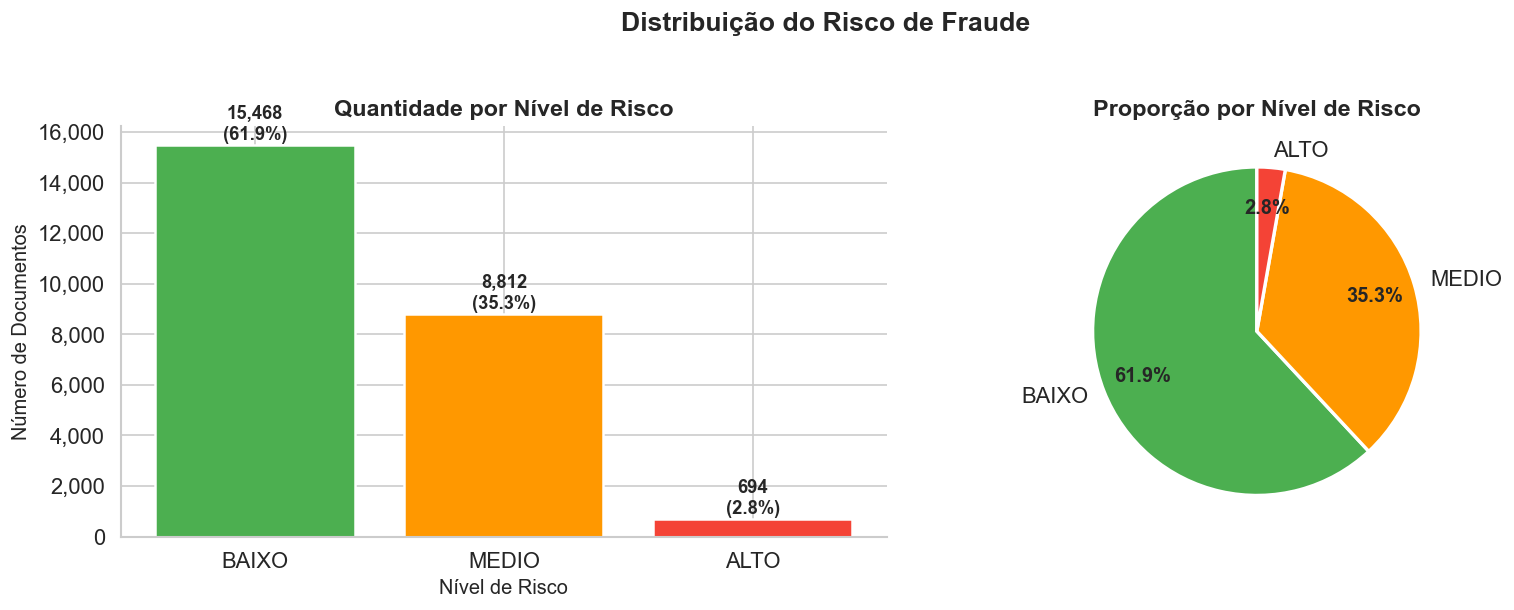

In [15]:
contagem = df["fraude_risco"].value_counts().reindex(["BAIXO", "MEDIO", "ALTO"])
pct      = contagem / contagem.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribuição do Risco de Fraude", fontsize=16, fontweight="bold", y=1.02)

# Barras
bars = axes[0].bar(contagem.index, contagem.values, color=CORES_RISCO, edgecolor="white", linewidth=1.5)
for bar, val, p in zip(bars, contagem.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Quantidade por Nível de Risco")
axes[0].set_ylabel("Número de Documentos")
axes[0].set_xlabel("Nível de Risco")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pizza
wedges, texts, autotexts = axes[1].pie(
    contagem.values, labels=contagem.index,
    colors=CORES_RISCO, autopct="%1.1f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
axes[1].set_title("Proporção por Nível de Risco")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fraude_01_distribuicao.png", bbox_inches="tight")
plt.show()

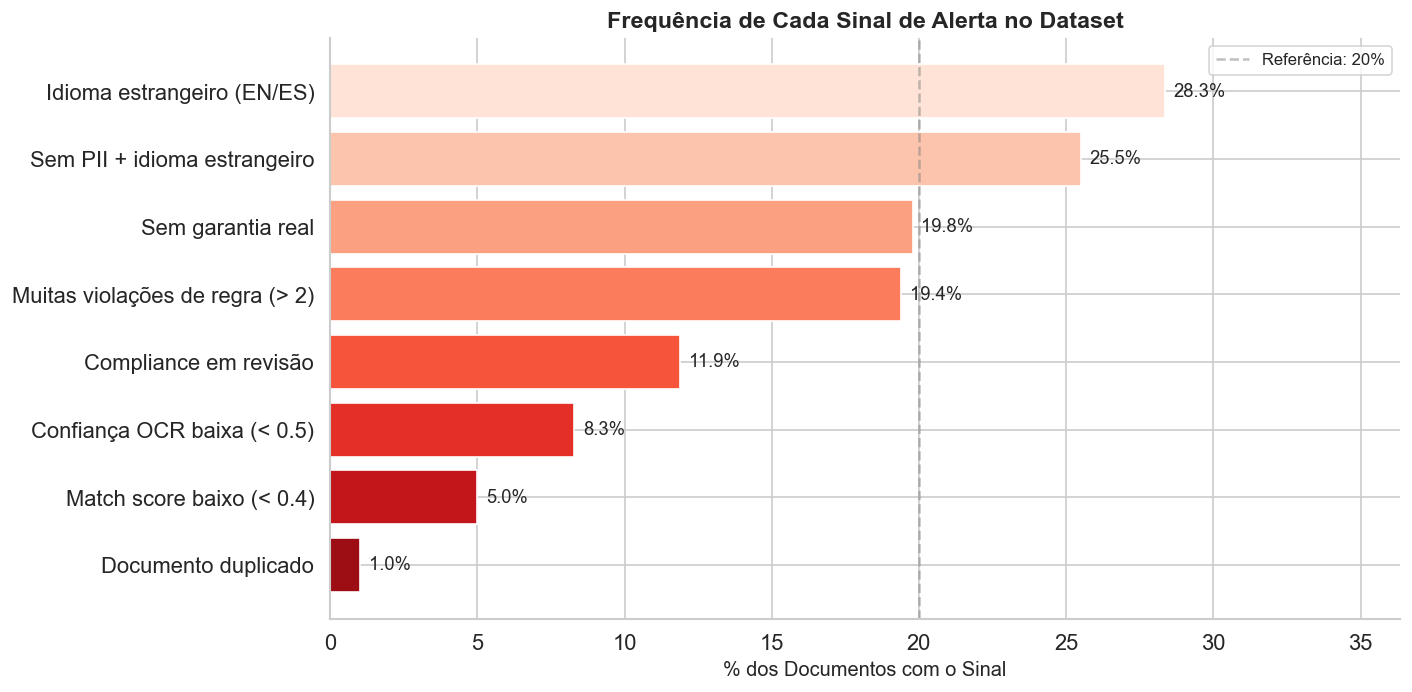

In [16]:
labels_sinais = {
    "fraude_idioma_estrangeiro" : "Idioma estrangeiro (EN/ES)",
    "fraude_sem_garantia"       : "Sem garantia real",
    "fraude_match_baixo"        : "Match score baixo (< 0.4)",
    "fraude_pii_idioma"         : "Sem PII + idioma estrangeiro",
    "fraude_muitas_violacoes"   : "Muitas violações de regra (> 2)",
    "fraude_duplicado"          : "Documento duplicado",
    "fraude_ocr_baixo"          : "Confiança OCR baixa (< 0.5)",
    "fraude_compliance_review"  : "Compliance em revisão",
}

freq = df[sinais].mean().rename(labels_sinais).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(freq.index, freq.values * 100,
               color=sns.color_palette("Reds_r", len(freq)), edgecolor="white")
for bar, val in zip(bars, freq.values):
    ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=11)

ax.set_title("Frequência de Cada Sinal de Alerta no Dataset")
ax.set_xlabel("% dos Documentos com o Sinal")
ax.set_xlim(0, freq.values.max() * 100 + 8)
ax.axvline(x=20, color="gray", linestyle="--", alpha=0.5, label="Referência: 20%")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fraude_02_sinais.png", bbox_inches="tight")
plt.show()

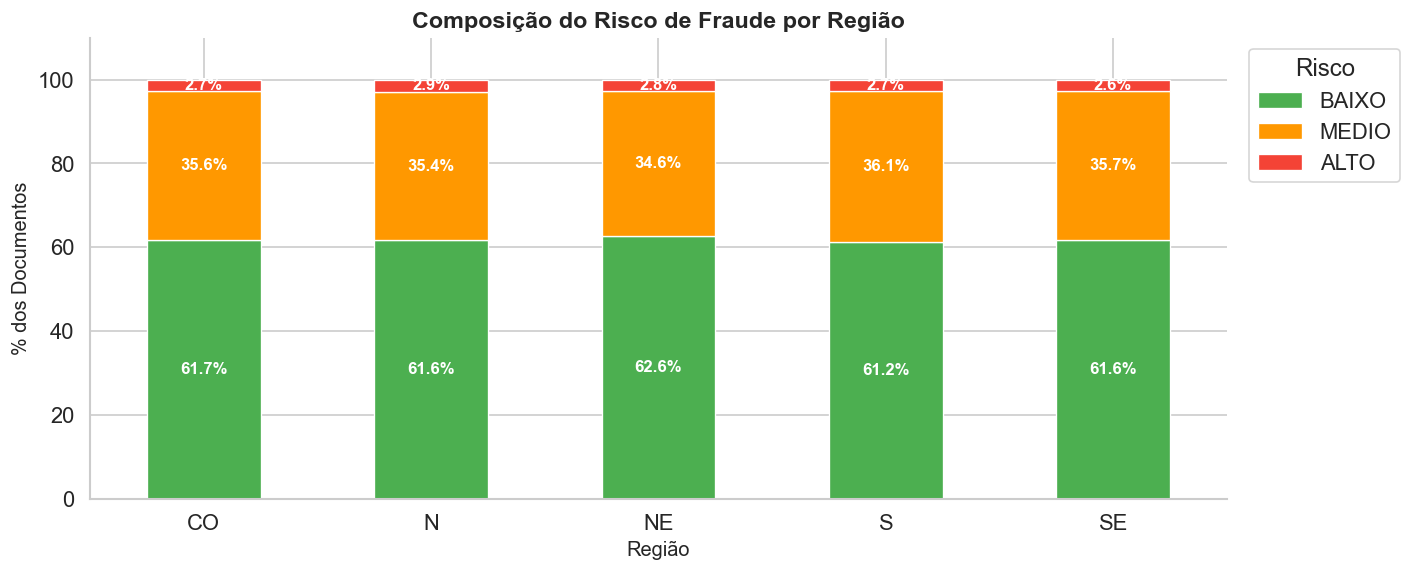

In [17]:
por_regiao = (
    df.groupby(["regiao", "fraude_risco"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["BAIXO", "MEDIO", "ALTO"])
)
por_regiao_pct = por_regiao.div(por_regiao.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
por_regiao_pct.plot(
    kind="bar", stacked=True, ax=ax,
    color=CORES_RISCO, edgecolor="white", linewidth=0.8
)

# Rótulos dentro das barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center",
                 fontsize=10, fontweight="bold", color="white")

ax.set_title("Composição do Risco de Fraude por Região")
ax.set_ylabel("% dos Documentos")
ax.set_xlabel("Região")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Risco", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fraude_03_por_regiao.png", bbox_inches="tight")

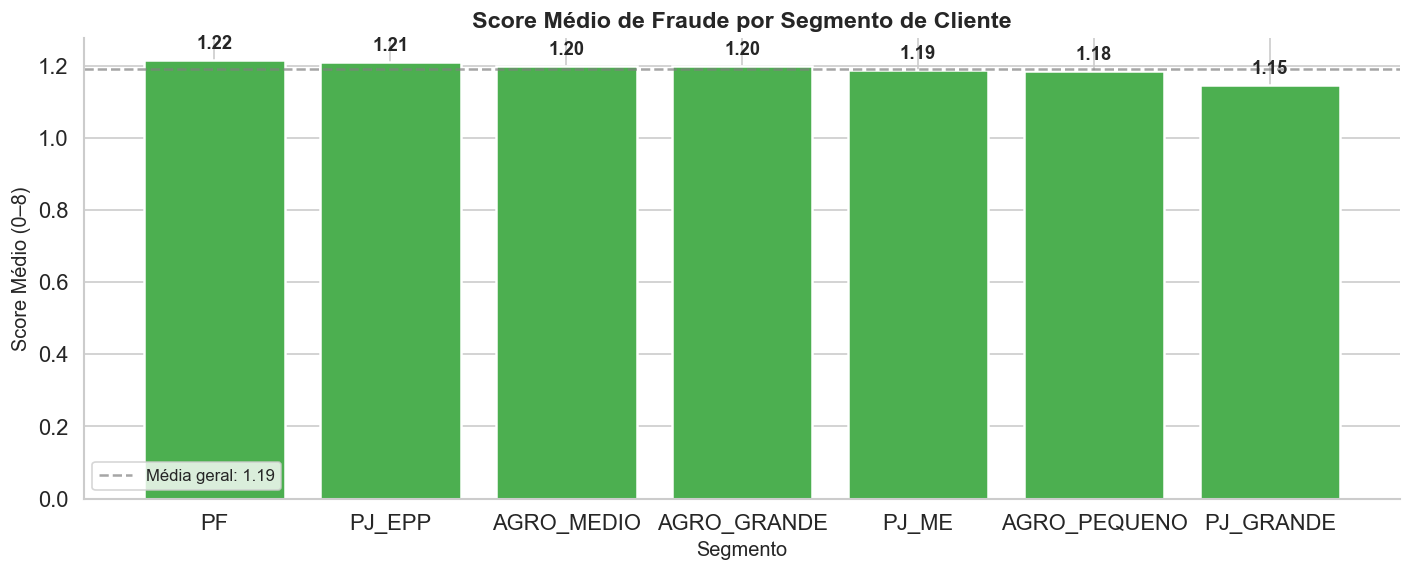

In [18]:
score_segmento = (
    df.groupby("customer_segment", observed=True)["fraude_score"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
cores = [COR_ALTO if v >= 2.5 else COR_MEDIO if v >= 2.0 else COR_BAIXO
         for v in score_segmento.values]
bars = ax.bar(score_segmento.index, score_segmento.values,
              color=cores, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, score_segmento.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Score Médio de Fraude por Segmento de Cliente")
ax.set_ylabel("Score Médio (0–8)")
ax.set_xlabel("Segmento")
ax.axhline(y=score_segmento.mean(), color="gray", linestyle="--",
           alpha=0.7, label=f"Média geral: {score_segmento.mean():.2f}")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fraude_04_por_segmento.png", bbox_inches="tight")
plt.show()

In [19]:
gold_fraude = (
    df.groupby(["regiao", "customer_segment"], observed=True)
    .agg(
        total_casos            = ("fraude_score", "count"),
        fraude_score_medio     = ("fraude_score", "mean"),
        pct_risco_alto         = ("fraude_risco", lambda x: (x == "ALTO").mean()),
        pct_risco_medio        = ("fraude_risco", lambda x: (x == "MEDIO").mean()),
        pct_idioma_estrangeiro = ("fraude_idioma_estrangeiro", "mean"),
        pct_sem_garantia       = ("fraude_sem_garantia", "mean"),
        pct_match_baixo        = ("fraude_match_baixo", "mean"),
        pct_pii_idioma         = ("fraude_pii_idioma", "mean"),
        pct_muitas_violacoes   = ("fraude_muitas_violacoes", "mean"),
        pct_duplicado          = ("fraude_duplicado", "mean"),
        pct_ocr_baixo          = ("fraude_ocr_baixo", "mean"),
        pct_compliance_review  = ("fraude_compliance_review", "mean"),
        default_rate           = ("default_12m", "mean"),
    )
    .round(4)
    .reset_index()
    .sort_values("fraude_score_medio", ascending=False)
)

casos_alto_risco = (
    df[df["fraude_risco"] == "ALTO"]
    [["doc_type", "ocr_engine", "text_language", "collateral_type",
      "match_score", "pii_detected", "rule_violations", "is_duplicate",
      "ocr_confidence", "compliance_status", "fraude_score",
      "customer_segment", "regiao", "default_12m"]]
    .sort_values("fraude_score", ascending=False)
    .reset_index(drop=True)
)
gold_fraude.to_csv(f"{GOLD_DATA_DIR}/gold_fraude.csv", index=False)
casos_alto_risco.to_csv(f"{GOLD_DATA_DIR}/gold_fraude_casos_alto_risco.csv", index=False)

print("✅ gold_fraude.csv salvo")
print("✅ gold_fraude_casos_alto_risco.csv salvo")
print(f"   Alto risco: {len(casos_alto_risco):,} casos ({len(casos_alto_risco)/len(df)*100:.1f}%)")

✅ gold_fraude.csv salvo
✅ gold_fraude_casos_alto_risco.csv salvo
   Alto risco: 694 casos (2.8%)
